In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [7]:
epochs, train_acc, val_acc = [], [], []
train_loss, val_loss = [], []

with open("training_log.jsonl") as f:
    for line in f:
        row = json.loads(line)
        epochs.append(row["epoch"])
        train_acc.append(row["train_acc"])
        val_acc.append(row["val_acc"])
        train_loss.append(row["train_loss"])
        val_loss.append(row["val_loss"])

In [8]:
PATIENCE = 10
EARLY_STOP = len(epochs) - PATIENCE - 1

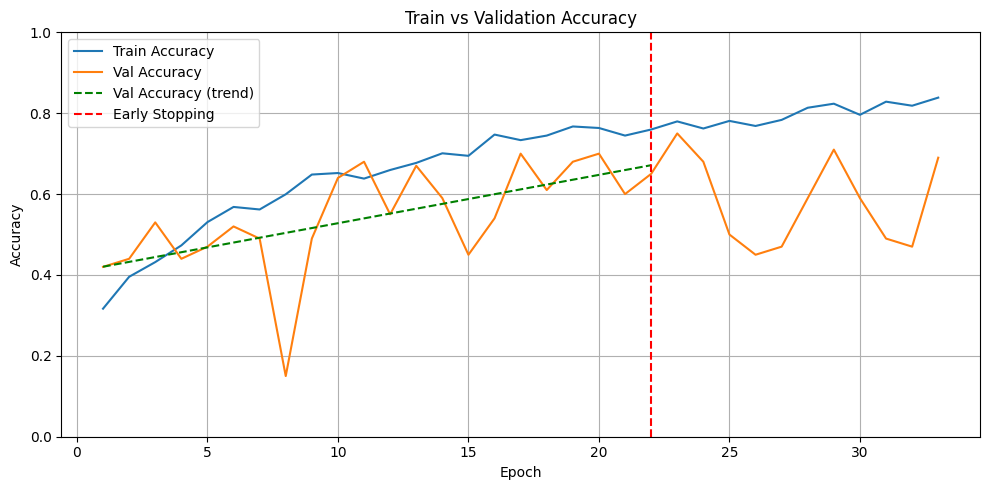

In [9]:
trend_acc = np.poly1d(np.polyfit(epochs[:EARLY_STOP], val_acc[:EARLY_STOP], 1))

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Val Accuracy")
plt.plot(epochs[:EARLY_STOP], trend_acc(epochs[:EARLY_STOP]), linestyle="--", color="green", label="Val Accuracy (trend)")
plt.axvline(x=EARLY_STOP, color="red", linestyle="--", label="Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

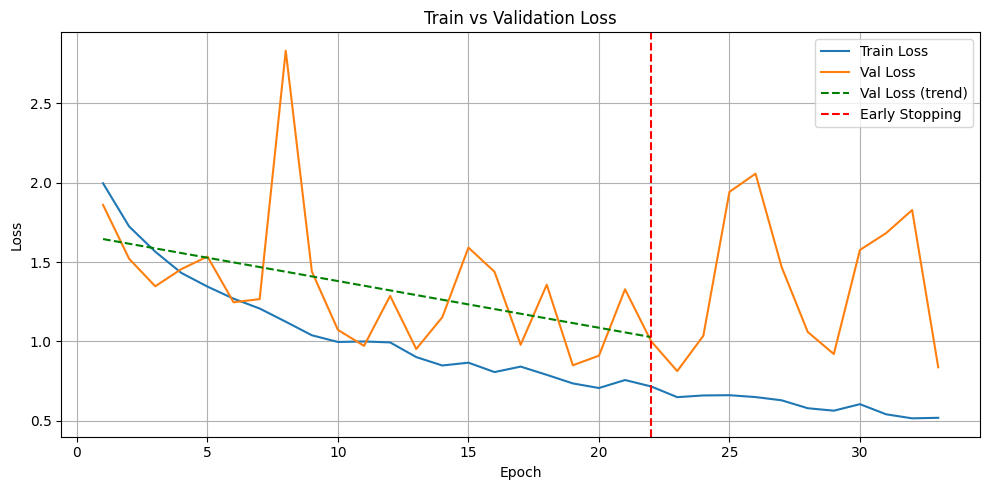

In [10]:
trend_loss = np.poly1d(np.polyfit(epochs[:EARLY_STOP], val_loss[:EARLY_STOP], 1))

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Val Loss")
plt.plot(epochs[:EARLY_STOP], trend_loss(epochs[:EARLY_STOP]), linestyle="--", color="green", label="Val Loss (trend)")
plt.axvline(x=EARLY_STOP, color="red", linestyle="--", label="Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()